In [1]:
import datasets
import pandas
import numpy as np
print(datasets.__version__)
print(pandas.__version__)

3.2.0
2.2.2


In [3]:
from datasets import load_dataset
ds = load_dataset('flwrlabs/femnist')

In [5]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'writer_id', 'hsf_id', 'character'],
        num_rows: 814277
    })
})


In [7]:
train_dataset = ds['train']
train_dataset[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'writer_id': 'f0000_14',
 'hsf_id': 0,
 'character': 0}

# Federated MNIST Dataset

https://huggingface.co/datasets/flwrlabs/femnist

* image: grayscale of size (28,28) PIL Image
* writer_id: string, unique value for each writer
* hsf_id: string, corresponds to the way that the data was collected
* character: ClassLabel - ASCII Value

In [10]:
train_dataset[0]['image']

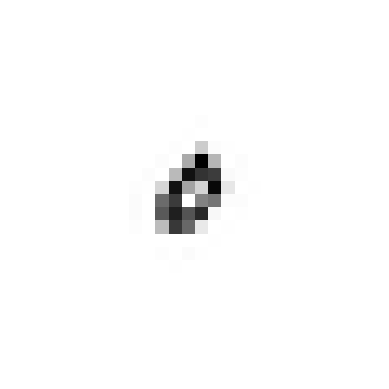

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

plt.imshow(train_dataset[0]['image'], cmap = 'gray')
plt.axis('off')
plt.show()

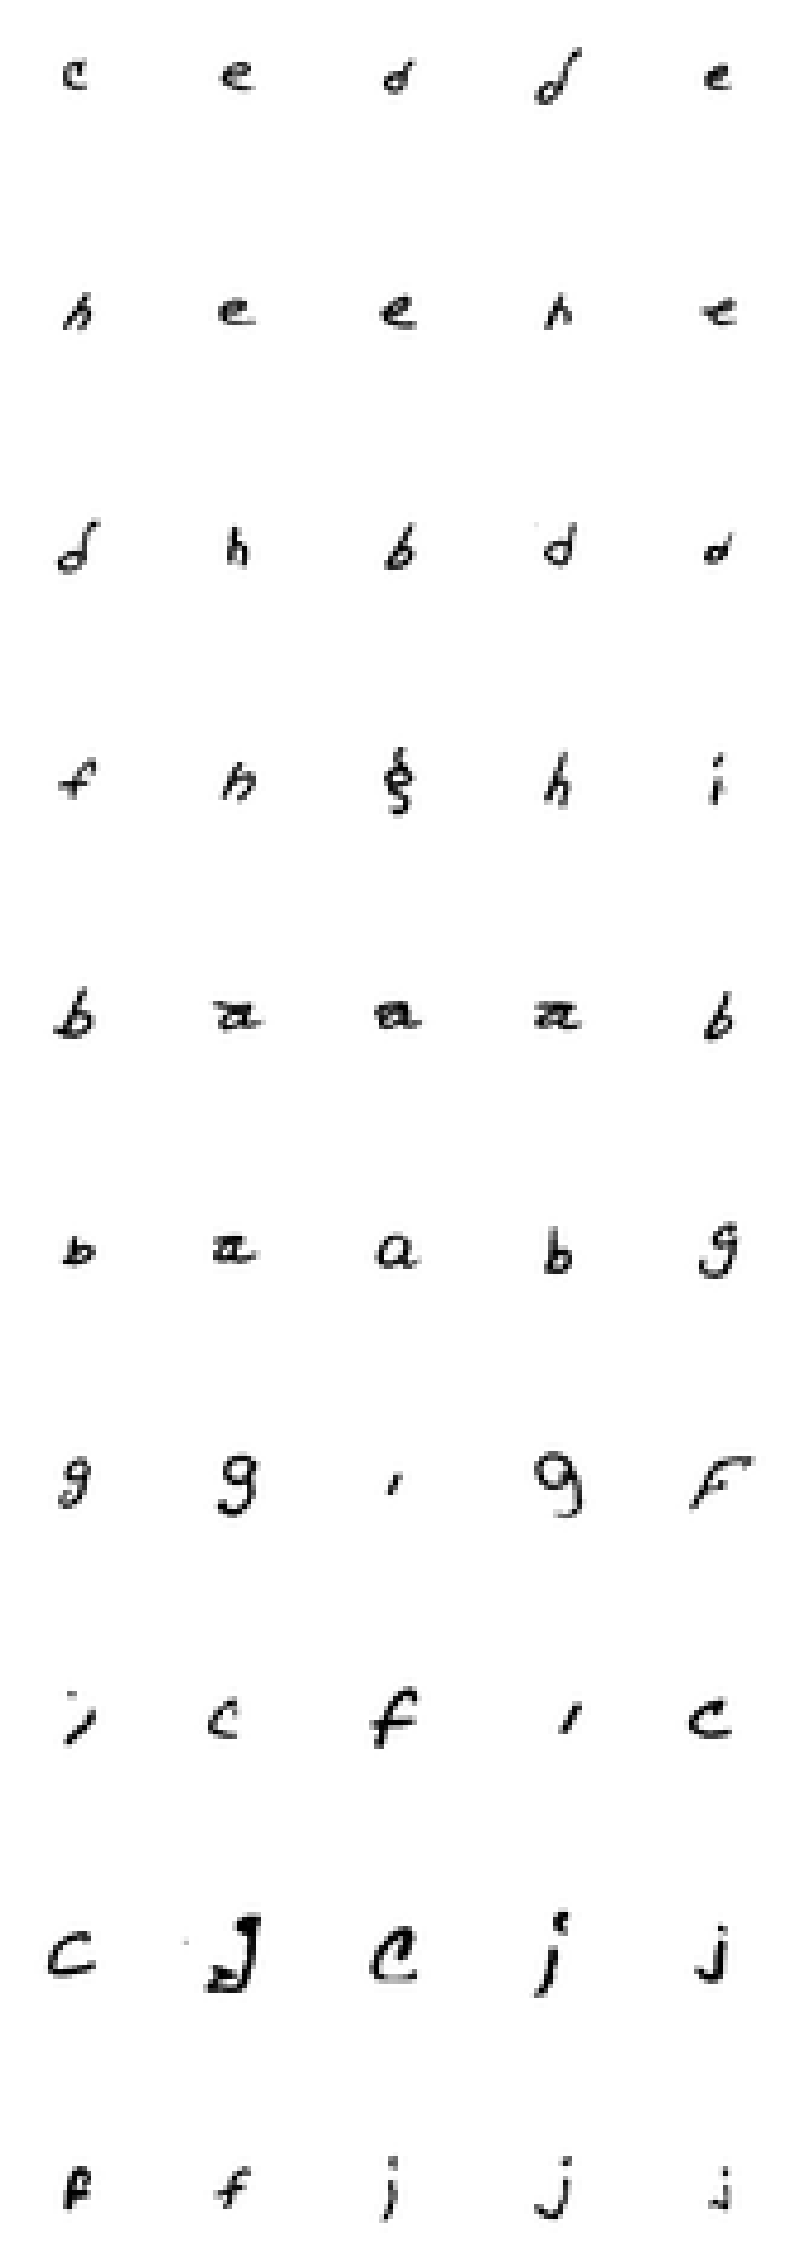

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def display_images(train_dataset, disp_cols=5, samples_per_char=5):
    char_counts = defaultdict(int)
    filtered_dataset = []
    
    for data in train_dataset:
        char = data['character']
        if 36 <= char <= 45 and char_counts[char] < samples_per_char:
            filtered_dataset.append(data)
            char_counts[char] += 1
    
    num_images = len(filtered_dataset)
    num_rows = int(np.ceil(num_images / disp_cols))
    
    fig, axes = plt.subplots(num_rows, disp_cols, figsize=(10, 3 * num_rows))
    axes = axes.ravel()
    
    for i, data in enumerate(filtered_dataset):
        image = data['image']
        axes[i].imshow(image, cmap='gray')
        axes[i].axis('off')
    
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.show()

display_images(train_dataset)


# Extract only letters a-j for each writer

In [19]:
train_dataset = ds['train']

print(ds['train'].features['character'].int2str(36))
print(ds['train'].features['character'].int2str(45))

train_dataset

a
j


Dataset({
    features: ['image', 'writer_id', 'hsf_id', 'character'],
    num_rows: 814277
})

In [21]:
only_a_j_dataset = train_dataset.filter(lambda x: 36 <= x['character'] <= 45)
print(len(only_a_j_dataset))

84381


In [23]:
print(only_a_j_dataset)

Dataset({
    features: ['image', 'writer_id', 'hsf_id', 'character'],
    num_rows: 84381
})


In [25]:
only_a_j_dataset[3]['image']

In [27]:
np_arr = np.array(only_a_j_dataset[0]['image'])
for i in range(len(np_arr)):
    for j in range(len(np_arr[i])):
        print(np_arr[i][j], end = " ")
    print()

img_arr = np_arr.flatten().reshape(784,1)
print(img_arr)

255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 
255 255 255 255 255 255 255 255 255 255 255 255 255 254 253 253 255 255 255 255 255 255 255 255 

In [29]:
from tqdm import tqdm
import pandas as pd

In [215]:
columns = ['image', 'writer_id', 'hsf_id', 'character']
df = pd.DataFrame(columns = columns)

for i in tqdm(range(len(only_a_j_dataset)), desc = 'Processing Images'):
    img = only_a_j_dataset[i]['image']
    np_arr = np.array(img)
    img_arr = np_arr.reshape(784)

    curr = only_a_j_dataset[i]
    
    writer_id = curr['writer_id']
    hsf_id = curr['hsf_id']
    char = curr['character']

    new_item = {
        'image' : img_arr,
        'writer_id' : writer_id,
        'hsf_id' : hsf_id,
        'character' : char
    }

    df.loc[len(df)] = new_item

df.head()

NameError: name 'tqdm' is not defined

In [41]:
for i in range(36,46):
    print(len(df[df['character'] == i][:2000]))

2000 of each letter -> 10 clients -> 20,000 images -> assign randomly to 10 clients

random sampling - similar effect

client_1 - 200 a's, 200 b's, ...
client_2 - 200 a's

ensure similar distribution - okay for some variance in frequency of each letter across client

11677
6012
3287
11860
28724
2962
4276
10217
3152
2214


In [ ]:
#cross device (5400 data for 200 clients) vs. cross silo (20000 data for 10 clients)

In [56]:
print(df['image'][0] == df['image'][1])

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T

# Saving Preprocessed DataFrame

In [1]:
df.to_pickle('dataframe.pkl')

NameError: name 'df' is not defined

In [3]:
import pandas as pd
df_loaded = pd.read_pickle('dataframe.pkl')

In [5]:
df_loaded.head()

,image,writer_id,hsf_id,character
0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0000_14,0,38
1,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0000_14,0,40
2,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0000_14,0,39
3,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0000_14,0,39
4,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0000_14,0,40


In [7]:
print(df_loaded['image'][0] == df_loaded['image'][1])

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T

In [9]:
grouped_df = df_loaded.groupby('writer_id')
print(grouped_df.groups)

{'f0000_14': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61], 'f0001_41': [62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133], 'f0002_01': [134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205], 'f0003_42': [206, 207, 208, 209, 210,

In [11]:
print("Number of writers:", len(grouped_df.groups))

Number of writers: 3563


In [13]:
client_list = list(grouped_df.groups.keys())
client_list

['f0000_14',
 'f0001_41',
 'f0002_01',
 'f0003_42',
 'f0004_09',
 'f0005_26',
 'f0006_12',
 'f0007_14',
 'f0008_45',
 'f0009_06',
 'f0010_18',
 'f0011_13',
 'f0012_39',
 'f0013_38',
 'f0014_19',
 'f0015_48',
 'f0016_39',
 'f0017_07',
 'f0018_13',
 'f0019_38',
 'f0020_08',
 'f0021_34',
 'f0022_10',
 'f0023_08',
 'f0024_24',
 'f0025_13',
 'f0026_17',
 'f0027_29',
 'f0028_05',
 'f0029_05',
 'f0030_12',
 'f0031_02',
 'f0032_27',
 'f0033_49',
 'f0034_08',
 'f0035_19',
 'f0036_39',
 'f0037_16',
 'f0038_42',
 'f0039_14',
 'f0040_25',
 'f0041_30',
 'f0042_43',
 'f0043_10',
 'f0044_12',
 'f0045_12',
 'f0046_20',
 'f0047_00',
 'f0048_00',
 'f0049_32',
 'f0050_10',
 'f0051_42',
 'f0052_42',
 'f0053_23',
 'f0054_14',
 'f0055_09',
 'f0056_01',
 'f0057_20',
 'f0058_07',
 'f0059_21',
 'f0060_43',
 'f0061_45',
 'f0062_25',
 'f0063_38',
 'f0064_04',
 'f0065_00',
 'f0066_37',
 'f0067_25',
 'f0068_00',
 'f0069_14',
 'f0070_14',
 'f0071_21',
 'f0072_36',
 'f0073_45',
 'f0074_07',
 'f0075_46',
 'f0076_06',

In [15]:
print(len(client_list))

3563


# Choose 200 random clients for sampling

In [18]:
import numpy as np
np.random.seed(42)

client_array = np.array(client_list)

def choose_clients(client_array, n):
    selected_clients = np.random.choice(client_array, size = n, replace = False)
    return selected_clients

client_subset = choose_clients(client_array, 200)
client_subset

array(['f2303_66', 'f0184_49', 'f3257_17', 'f1363_19', 'f3388_36',
       'f0765_33', 'f0211_26', 'f0179_22', 'f1410_19', 'f0883_14',
       'f3618_26', 'f3439_44', 'f3924_24', 'f2329_94', 'f2226_85',
       'f1075_00', 'f1347_06', 'f1768_48', 'f2338_70', 'f0574_03',
       'f3636_24', 'f1294_12', 'f3577_03', 'f3365_46', 'f2275_90',
       'f2435_57', 'f2241_88', 'f0314_27', 'f1478_41', 'f0987_34',
       'f0651_45', 'f0279_03', 'f0070_14', 'f2532_93', 'f2595_89',
       'f3304_23', 'f0595_35', 'f2506_77', 'f0203_21', 'f2052_11',
       'f3689_09', 'f1198_41', 'f1368_03', 'f3660_26', 'f0658_30',
       'f3300_25', 'f1741_16', 'f1387_23', 'f0730_41', 'f2459_55',
       'f4004_35', 'f3907_43', 'f4068_21', 'f0251_00', 'f3693_03',
       'f1986_20', 'f0606_11', 'f1076_12', 'f0093_24', 'f1189_06',
       'f1244_09', 'f1960_26', 'f0411_01', 'f2114_50', 'f1151_39',
       'f3193_08', 'f0545_49', 'f0458_38', 'f1870_30', 'f0358_32',
       'f1077_48', 'f0914_27', 'f4064_46', 'f0643_23', 'f0487_

In [20]:
df_filtered = df_loaded[df_loaded['writer_id'].isin(client_subset)]

# verify that only 200 groups remain
temp_df = df_filtered.groupby('writer_id')
print(len(temp_df.groups))

df_filtered.reset_index(drop = True, inplace = True)
df_filtered

200


,image,writer_id,hsf_id,character
0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40
1,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,36
2,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43
3,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43
4,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40
...,...,...,...,...
5408,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,37
5409,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,36
5410,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,38
5411,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,39


In [22]:
def select_random_characters(group, num_classes):

    distinct_characters = group['character'].unique()
    num_classes_to_select = min(num_classes, len(distinct_characters))

    selected_characters = np.random.choice(distinct_characters, size = num_classes_to_select, replace = False)
    return group[group['character'].isin(selected_characters)]

num_classes = 10

df_filtered_selected = df_filtered.groupby('writer_id', group_keys = False).apply(select_random_characters, num_classes = num_classes)
df_filtered_selected.reset_index(drop = True, inplace = True)

df_filtered_selected

/var/folders/1f/vmz43dnn7sd609gnr33rxxhr0000gn/T/ipykernel_26967/1025090380.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_filtered_selected = df_filtered.groupby('writer_id', group_keys = False).apply(select_random_characters, num_classes = num_classes)


,image,writer_id,hsf_id,character
0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40
1,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,36
2,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43
3,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43
4,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40
...,...,...,...,...
5408,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,37
5409,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,36
5410,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,38
5411,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,39


In [24]:
writer_classes_df = df_filtered_selected.groupby('writer_id')['character'].unique()
writer_classes_df = writer_classes_df.reset_index()
writer_classes_df.columns = ['writer_id', 'character_classes']

writer_classes_df

,writer_id,character_classes
0,f0017_07,"[40, 36, 43, 44, 39, 42, 37, 41, 45, 38]"
1,f0026_17,"[43, 42, 38, 41, 40, 45, 39, 44, 36, 37]"
2,f0030_12,"[37, 43, 40, 36, 45, 39, 42, 44, 38]"
3,f0032_27,"[36, 42, 40, 39, 37, 44, 45, 43, 38, 41]"
4,f0051_42,"[39, 37, 44, 36, 45, 40, 43, 42, 38]"
...,...,...
195,f4054_12,"[43, 38, 36, 37, 40, 39]"
196,f4064_46,"[37, 38, 42, 39, 41, 43, 40]"
197,f4068_21,"[37, 45, 43, 40, 41, 38, 36, 39, 42]"
198,f4088_26,"[40, 39, 37, 43, 44, 36, 41]"


In [26]:
array = writer_classes_df.iloc[0,1]
array

array([40, 36, 43, 44, 39, 42, 37, 41, 45, 38])

In [28]:
for w in writer_classes_df['writer_id']:
    print(w)

f0017_07
f0026_17
f0030_12
f0032_27
f0051_42
f0052_42
f0070_14
f0076_06
f0093_24
f0134_33
f0139_23
f0144_05
f0179_22
f0184_49
f0196_10
f0203_21
f0211_26
f0229_10
f0251_00
f0270_23
f0279_03
f0289_10
f0291_06
f0295_17
f0314_27
f0351_22
f0358_32
f0387_49
f0393_18
f0410_43
f0411_01
f0415_28
f0458_38
f0462_07
f0487_42
f0502_09
f0545_49
f0555_35
f0565_03
f0574_03
f0595_35
f0603_11
f0606_11
f0613_28
f0622_25
f0643_23
f0645_45
f0651_45
f0658_30
f0692_03
f0730_41
f0762_20
f0765_33
f0777_12
f0803_40
f0840_37
f0841_10
f0844_42
f0849_38
f0871_23
f0881_03
f0883_14
f0914_27
f0923_31
f0939_32
f0966_44
f0987_34
f1005_12
f1029_30
f1034_02
f1039_40
f1072_34
f1075_00
f1076_12
f1077_48
f1086_15
f1112_30
f1151_39
f1180_21
f1189_06
f1198_41
f1213_10
f1222_04
f1228_30
f1238_43
f1244_09
f1253_43
f1270_28
f1272_09
f1294_12
f1341_45
f1347_06
f1363_19
f1368_03
f1387_23
f1410_19
f1449_22
f1478_41
f1490_31
f1510_28
f1541_40
f1591_47
f1607_17
f1628_45
f1664_04
f1672_35
f1686_01
f1703_29
f1741_16
f1753_34
f1759_19
f

In [30]:
writer_classes_df = df_filtered_selected.groupby('writer_id')['character'].unique()
writer_classes_df = writer_classes_df.reset_index()

writer_classes_df.columns = ['writer_id', 'character_classes']

def count_items_in_classes(writer_id, character_classes):
    filtered_rows = df_filtered_selected[(df_filtered_selected['writer_id'] == writer_id) 
    & (df_filtered_selected['character'].isin(character_classes))]

    return len(filtered_rows)

writer_classes_df['num_items'] = writer_classes_df.apply(lambda row: count_items_in_classes(row['writer_id'], row['character_classes']), axis=1)
writer_classes_df

,writer_id,character_classes,num_items
0,f0017_07,"[40, 36, 43, 44, 39, 42, 37, 41, 45, 38]",84
1,f0026_17,"[43, 42, 38, 41, 40, 45, 39, 44, 36, 37]",10
2,f0030_12,"[37, 43, 40, 36, 45, 39, 42, 44, 38]",35
3,f0032_27,"[36, 42, 40, 39, 37, 44, 45, 43, 38, 41]",45
4,f0051_42,"[39, 37, 44, 36, 45, 40, 43, 42, 38]",58
...,...,...,...
195,f4054_12,"[43, 38, 36, 37, 40, 39]",8
196,f4064_46,"[37, 38, 42, 39, 41, 43, 40]",7
197,f4068_21,"[37, 45, 43, 40, 41, 38, 36, 39, 42]",9
198,f4088_26,"[40, 39, 37, 43, 44, 36, 41]",8


In [32]:
writer_classes_df = df_filtered_selected.groupby('writer_id')['character'].unique()
writer_classes_df = writer_classes_df.reset_index()

writer_classes_df.columns = ['writer_id', 'character_classes']

def count_items_in_classes(writer_id, character_classes, label):
    filtered_rows = df_filtered_selected[(df_filtered_selected['writer_id'] == writer_id) 
    & (df_filtered_selected['character'].isin([label]))]

    return len(filtered_rows)

letters = {
    36 : 'a', 
    37 : 'b',
    38 : 'c',
    39 : 'd',
    40 : 'e',
    41 : 'f',
    42 : 'g',
    43 : 'h',
    44 : 'i',
    45 : 'j',
}

for i in range(36, 46):
    writer_classes_df['num_items_' + letters[i]] = writer_classes_df.apply(lambda row: count_items_in_classes(row['writer_id'], row['character_classes'], i), axis=1)
writer_classes_df

,writer_id,character_classes,num_items_a,num_items_b,num_items_c,num_items_d,num_items_e,num_items_f,num_items_g,num_items_h,num_items_i,num_items_j
0,f0017_07,"[40, 36, 43, 44, 39, 42, 37, 41, 45, 38]",14,3,1,11,38,1,2,11,2,1
1,f0026_17,"[43, 42, 38, 41, 40, 45, 39, 44, 36, 37]",1,1,1,1,1,1,1,1,1,1
2,f0030_12,"[37, 43, 40, 36, 45, 39, 42, 44, 38]",4,4,1,6,12,0,2,4,1,1
3,f0032_27,"[36, 42, 40, 39, 37, 44, 45, 43, 38, 41]",10,3,1,10,13,1,1,4,1,1
4,f0051_42,"[39, 37, 44, 36, 45, 40, 43, 42, 38]",13,4,1,8,14,0,4,11,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...
195,f4054_12,"[43, 38, 36, 37, 40, 39]",2,1,2,1,1,0,0,1,0,0
196,f4064_46,"[37, 38, 42, 39, 41, 43, 40]",0,1,1,1,1,1,1,1,0,0
197,f4068_21,"[37, 45, 43, 40, 41, 38, 36, 39, 42]",1,1,1,1,1,1,1,1,0,1
198,f4088_26,"[40, 39, 37, 43, 44, 36, 41]",1,1,0,1,2,1,0,1,1,0


In [34]:
df_filtered_selected

,image,writer_id,hsf_id,character
0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40
1,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,36
2,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43
3,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43
4,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40
...,...,...,...,...
5408,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,37
5409,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,36
5410,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,38
5411,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,39


In [36]:
writer_id_list = []
for w in df_filtered_selected['writer_id'].unique():
    writer_id_list.append(w)

def create_U(writer_id_list):

    U = dict()

    for w_id in writer_id_list:
    
        matches = df_filtered_selected[df_filtered_selected['writer_id'] == w_id]

        U_i = []

        for i in range(len(matches['image'])):
            U_i.append(matches['image'].iloc[i])

        U_i = np.array(U_i)
        U[w_id] = U_i

    return U

def create_v(writer_id_list, binary):

    v = dict()

    for w_id in writer_id_list:

        matches = df_filtered_selected[df_filtered_selected['writer_id'] == w_id]

        v_i = []

        for i in range(len(matches['image'])):

            if binary:
                label = 1 if matches['character'].iloc[i] == 36 else -1
            else:
                label = matches['character'].iloc[i]

            v_i.append(label)

        v_i = np.array(v_i)

        v[w_id] = v_i

    return v

U = create_U(writer_id_list)
v = create_v(writer_id_list, binary = True)

writer = 'f0017_07'
print(U[writer].shape)
print(v[writer].shape)

(84, 784)
(84,)


In [38]:
def df_U_i(writer_id):
    df_U_i = pd.DataFrame(U[writer_id])
    return df_U_i

def df_v_i(writer_id):
    df_v_i = pd.DataFrame(v[writer_id])
    return df_v_i

In [40]:
df_U_0 = df_U_i(writer)
df_U_0

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
2,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
3,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
4,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
80,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
81,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
82,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255


In [42]:
df_v_0 = df_v_i(writer)
df_v_0

,0
0,-1
1,1
2,-1
3,-1
4,-1
...,...
79,-1
80,-1
81,-1
82,-1


In [44]:
v

{'f0017_07': array([-1,  1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
        -1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,
        -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1,  1, -1,  1, -1,
         1, -1,  1, -1, -1,  1,  1, -1, -1,  1, -1, -1, -1, -1, -1, -1]),
 'f0026_17': array([-1, -1, -1, -1, -1, -1, -1, -1,  1, -1]),
 'f0030_12': array([-1, -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,  1, -1, -1, -1, -1,
        -1]),
 'f0032_27': array([ 1,  1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1, -1, -1,
        -1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1,  1,
        -1,  1, -1, -1, -1, -1, -1, -1,  1, -1,  1]),
 'f0051_42': array([-1, -1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1, -1,
        -1, -1, -1,  1, -1,  1, -1, -1, -1, -1, -1, -1, -1, -1, 

In [46]:
n = 784
N = 5413
x_global = np.ones((n,1))
x_global

mu = 10 ** -2

In [48]:
from numpy import linalg as LA
from math import log, exp

In [50]:
def obj_f(U, v, x):
    vU = U * v[:, np.newaxis][0]
    vUx = -np.dot(vU.T, x)
    N = U.shape[1]
    return (mu * LA.norm(x) ** 2) + sum([vUx[i,0] if vUx[i,0] > 709 else log(1 + exp(vUx[i,0])) for i in range(N)])/N

In [52]:
df_filtered['label'] = df_filtered['character'].apply(lambda x: 1 if x == 36 else -1)
df_filtered

/var/folders/1f/vmz43dnn7sd609gnr33rxxhr0000gn/T/ipykernel_26967/2038457443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['label'] = df_filtered['character'].apply(lambda x: 1 if x == 36 else -1)


,image,writer_id,hsf_id,character,label
0,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40,-1
1,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,36,1
2,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43,-1
3,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,43,-1
4,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f0017_07,0,40,-1
...,...,...,...,...,...
5408,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,37,-1
5409,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,36,1
5410,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,38,-1
5411,"[255, 255, 255, 255, 255, 255, 255, 255, 255, ...",f4092_24,7,39,-1


In [54]:
image_arrays = np.array(df_filtered['image'].tolist())
U_matrix = image_arrays.T
U_matrix.shape

(784, 5413)

In [56]:
v_vector = np.array([df_filtered['label'].tolist()])
v_vector.shape

(1, 5413)

In [58]:
obj_f(U_matrix, v_vector, x_global)

164660.7417180861

In [60]:
client_list = list(U.keys())
print(client_list)

['f0017_07', 'f0026_17', 'f0030_12', 'f0032_27', 'f0051_42', 'f0052_42', 'f0070_14', 'f0076_06', 'f0093_24', 'f0134_33', 'f0139_23', 'f0144_05', 'f0179_22', 'f0184_49', 'f0196_10', 'f0203_21', 'f0211_26', 'f0229_10', 'f0251_00', 'f0270_23', 'f0279_03', 'f0289_10', 'f0291_06', 'f0295_17', 'f0314_27', 'f0351_22', 'f0358_32', 'f0387_49', 'f0393_18', 'f0410_43', 'f0411_01', 'f0415_28', 'f0458_38', 'f0462_07', 'f0487_42', 'f0502_09', 'f0545_49', 'f0555_35', 'f0565_03', 'f0574_03', 'f0595_35', 'f0603_11', 'f0606_11', 'f0613_28', 'f0622_25', 'f0643_23', 'f0645_45', 'f0651_45', 'f0658_30', 'f0692_03', 'f0730_41', 'f0762_20', 'f0765_33', 'f0777_12', 'f0803_40', 'f0840_37', 'f0841_10', 'f0844_42', 'f0849_38', 'f0871_23', 'f0881_03', 'f0883_14', 'f0914_27', 'f0923_31', 'f0939_32', 'f0966_44', 'f0987_34', 'f1005_12', 'f1029_30', 'f1034_02', 'f1039_40', 'f1072_34', 'f1075_00', 'f1076_12', 'f1077_48', 'f1086_15', 'f1112_30', 'f1151_39', 'f1180_21', 'f1189_06', 'f1198_41', 'f1213_10', 'f1222_04', 'f1

In [62]:
x_dict = dict()
for c in client_list:
    x_dict[c] = np.ones((n,1))    

In [64]:
x_global = np.mean(np.array(list(x_dict.values())), axis = 0)
x_global.shape

(784, 1)

In [66]:
def stoch_grad_F(x, client_id, i): 
    U_c = U[client_id].T
    v_c = np.array([v[client_id]])
    vU = U_c * v_c[:, np.newaxis][0]
    return (mu * x) + (-vU[:, [i]] / (1 + np.exp(min(709, np.dot(vU[:, [i]].T, x)[0, 0]))))


In [68]:
client_id = 'f0017_07'
print(U[client_id])
print(len(U[client_id]))
print(len(U[client_id][0]))
print(U[client_id].T.shape)

print(np.array([v[client_id]]).shape)

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
84
784
(784, 84)
(1, 84)


In [70]:
stoch_grad_F(x_global, 'f0017_07', 0) # output is a 784 by 1 vector
# last parameter can be 0-83 inclusive because 84 items for client 'f0017_07'

array([[2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.5501e+02],
       [2.550

In [72]:
def SGD(x_0, client_id, k_max, stepsize, epoch_length, minibatch_size):
    x_epoch_vals = dict()
    x_epoch_vals[0] = x_0
    x_next = x_0
    N_specific = len(U[client_id])
    for k in range(k_max):
        x_now = x_next
        minibatch_indices = list(np.random.randint(N_specific, size = minibatch_size))
        mini_batch_stoch_grad = sum(stoch_grad_F(x_now, client_id, i) for i in minibatch_indices)/minibatch_size
        x_next = x_now - stepsize * mini_batch_stoch_grad

        if ((k + 1) % epoch_length) == 0:
            x_epoch_vals[(k+1)//epoch_length] = x_next

    return x_epoch_vals

In [74]:
n_epoch = 10
minibatch_size = 1
curr_client_id = 'f0017_07'
print(len(U[curr_client_id]))
N_curr = len(U[curr_client_id])

k_max_SGD = int(N_curr * n_epoch / minibatch_size)
epoch_length_SGD = int(k_max_SGD/n_epoch)
print(k_max_SGD, epoch_length_SGD)

stepsize_choices = [10 ** -7, 10 ** -6, 10 ** -5, 10 ** -4]

84
840 84


In [76]:
m = 200 # number of devices

In [78]:
np.random.seed(42)
x_epoch_vals = SGD(x_global, 'f0017_07', k_max_SGD, stepsize_choices[3], epoch_length_SGD, minibatch_size)
# print(x_epoch_vals.values())

In [80]:
print(x_epoch_vals.keys())
for x_e_val in x_epoch_vals:
    print(obj_f(U['f0017_07'].T,np.array([v['f0017_07']]),x_epoch_vals[x_e_val]))

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
162736.73285714287
51.164603059523074
30.929603707144707
21.076864584715505
132.6729442441091
96.60864489768356
3327.7860583002557
11.296197118038876
8.023238750334484
6.268206624790722
5.99744772618428


In [82]:
# Federated Averaging

np.random.seed(42)

stepsize = stepsize_choices[3]
H = 5 # number of iterations per client use H for k_max
m = 200 # clients
R = 20 # communication rounds

N_total = len(df_filtered)
print(N_total)

x_global_list = [x_global]
x_epoch_vals_by_client = dict()

local_objectives = dict()

for c in client_list:
    x_epoch_vals_by_client[c] = []

for r in range(R): # for each communication round

    #print("Round:", r)

    # Distribute global model to each client
    curr_global = x_global_list[-1]

    #print("curr_global", curr_global)

    next_global = np.zeros((784,1))
    
    for c in client_list : # for each client

        # print("Client:", c)
        
        N_curr = len(U[c])

        # print("Data per client:", N_curr)
        
        k_max_SGD = int(N_curr * n_epoch / minibatch_size)
        epoch_length_SGD = k_max_SGD // n_epoch

        # print("Parameters:", "k_max_SGD:", k_max_SGD, "epoch_length_SGD", epoch_length_SGD)

        # Each client trains model locally using its own data via SGD
        SGD_result = SGD(curr_global, c, k_max_SGD, stepsize, epoch_length_SGD, minibatch_size) 
        # SGD_result is a dictionary
        # keys = iteration
        # values = local_sol
        x_epoch_vals_by_client[c].extend(list(SGD_result.values()))

        # Collect local model updates/weights from all clients
        curr_local_sol = x_epoch_vals_by_client[c][-1]
        #print("curr_local_sol", curr_local_sol)
        #print("type of curr_local_sol", type(curr_local_sol))

        # Aggregate updates using weighted average
        next_global += curr_local_sol * N_curr

    # update global model with aggregated parameters
    #print("new x_global:", next_global / N_total)
    x_global_list.append(next_global / N_total)

# print(x_global_list)


5413


In [83]:
# local objective function values for first client
print(len(x_global_list))
for x_val in x_global_list:
    print(obj_f(U['f0017_07'].T,np.array([v['f0017_07']]),x_val))

21
162736.73285714287
175.09765997064443
84.8625863263826
75.47019557571642
68.3483386863183
110.21881339507932
69.5767889873166
88.01903764075544
110.01722276475626
73.39851236368888
115.56626474383206
105.34502942944216
91.00821529786782
122.62162920458013
102.7623313716449
132.37091415353052
135.26729556891257
109.22234521015844
95.81145310514498
132.26425635328928
111.98969944484605


In [84]:
# global objective function values

for x_val in x_global_list:
    print(obj_f(U_matrix, v_vector, x_val))

164660.7417180861
228.85986641391395
131.6598033902256
109.91349848141947
94.79530304862443
118.91040058174327
85.00675672683079
93.677995501743
104.9807733203714
79.61479215115345
103.04593321536592
96.00902921873922
85.99160711181622
102.28319004841248
90.4876323343559
104.8929693852207
106.03325596455512
92.0911212555809
85.44070159455445
101.25071662592792
91.34194714411566


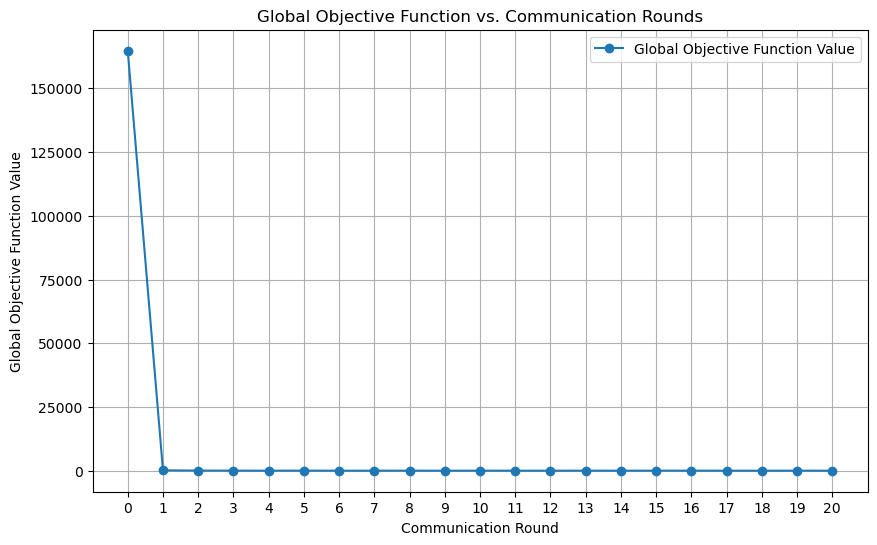

In [85]:
import matplotlib.pyplot as plt

objective_values = []

for x_val in x_global_list:
    obj_val = obj_f(U_matrix, v_vector, x_val)
    objective_values.append(obj_val)

communication_rounds = range(len(objective_values))

plt.figure(figsize=(10, 6))
plt.plot(communication_rounds, objective_values, marker='o', label='Global Objective Function Value')
plt.xticks(communication_rounds)
plt.xlabel('Communication Round')
plt.ylabel('Global Objective Function Value')
plt.title('Global Objective Function vs. Communication Rounds')
plt.legend()
plt.grid(True)
plt.show()

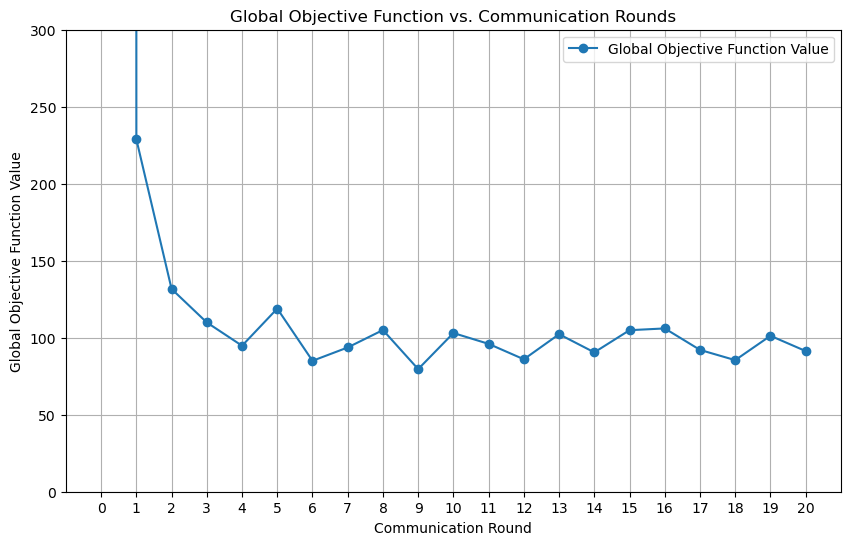

In [86]:
import matplotlib.pyplot as plt

objective_values = []

for x_val in x_global_list:
    obj_val = obj_f(U_matrix, v_vector, x_val)
    objective_values.append(obj_val)

communication_rounds = range(len(objective_values))

plt.figure(figsize=(10, 6))
plt.plot(communication_rounds, objective_values, marker='o', label='Global Objective Function Value')
plt.xticks(communication_rounds)
plt.xlabel('Communication Round')
plt.ylabel('Global Objective Function Value')
plt.title('Global Objective Function vs. Communication Rounds')
plt.legend()
plt.grid(True)
plt.ylim(0,300)
plt.show()

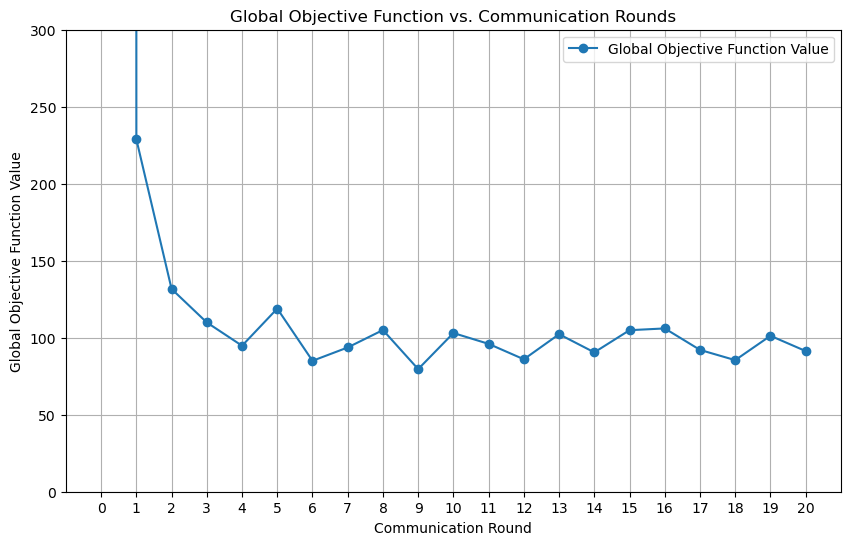

In [92]:
import matplotlib.pyplot as plt

objective_values = []

for x_val in x_global_list:
    obj_val = obj_f(U_matrix, v_vector, x_val)
    objective_values.append(obj_val)

communication_rounds = range(len(objective_values))

plt.figure(figsize=(10, 6))
plt.plot(communication_rounds, objective_values, marker='o', label='Global Objective Function Value')
plt.xticks(communication_rounds)
plt.xlabel('Communication Round')
plt.ylabel('Global Objective Function Value')
plt.title('Global Objective Function vs. Communication Rounds')
plt.legend()
plt.grid(True)
plt.ylim(0,300)
plt.show()

/var/folders/1f/vmz43dnn7sd609gnr33rxxhr0000gn/T/ipykernel_26967/613527034.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


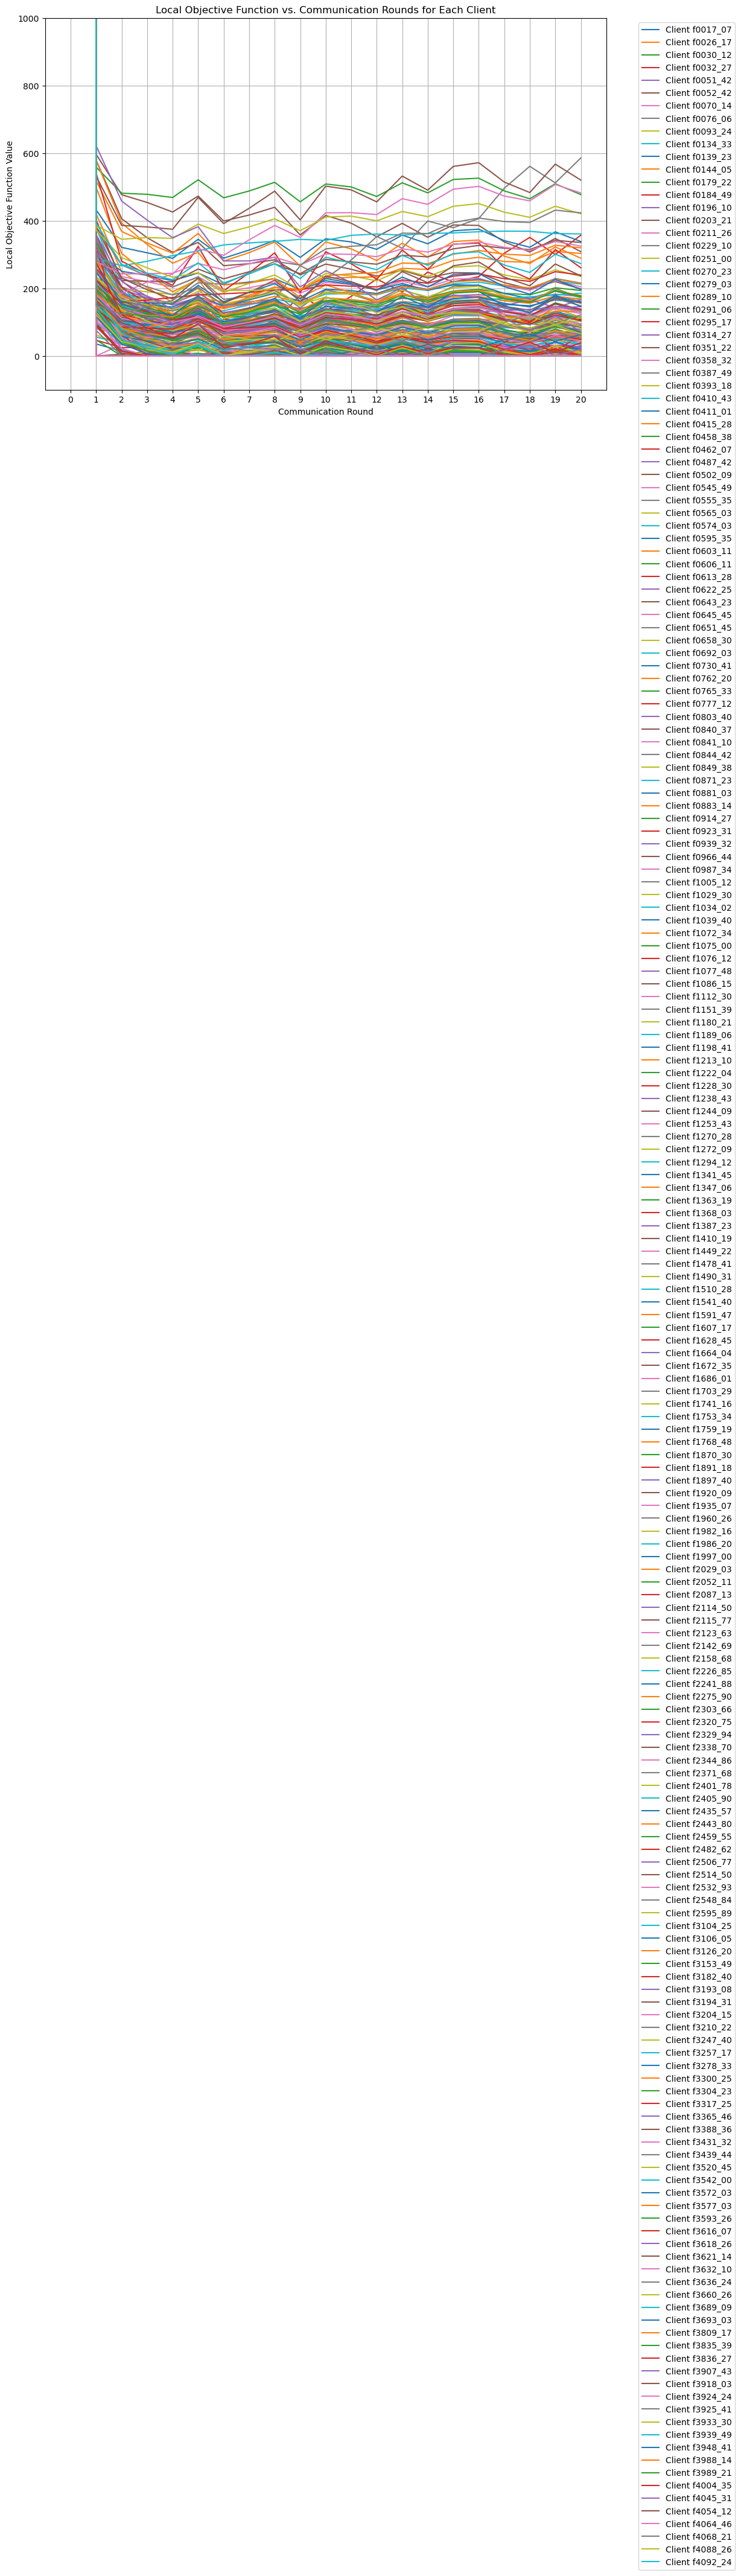

In [94]:
import matplotlib.pyplot as plt

local_objective_values = {client: [] for client in client_list}

for x_val in x_global_list:
    for client in client_list:
        obj_val = obj_f(U[client].T, np.array([v[client]]), x_val)
        local_objective_values[client].append(obj_val)

plt.figure(figsize=(12, 8))
for client, obj_values in local_objective_values.items():
    plt.plot(range(len(obj_values)), obj_values, label=f'Client {client}')

plt.xlabel('Communication Round')
plt.ylabel('Local Objective Function Value')
plt.xticks(communication_rounds)
plt.title('Local Objective Function vs. Communication Rounds for Each Client')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.ylim(-100,1000)
plt.tight_layout()
plt.show()

In [ ]:
# run whole fed avg method multiple times
# replicate fed avg code for each add'l sample path
# collect and average outputs at each epoch
# homogeneous setting - ensure convergence
# tune hyperparameters for convergence

In [96]:
import numpy as np

np.random.seed(42)

num_runs = 10  # Number of times to run Federated Averaging
all_sample_paths = [] 

stepsize = stepsize_choices[3]
H = 5
m = 200
R = 20

N_total = len(df_filtered)

for run in range(num_runs):
    x_global_list = [x_global]
    x_epoch_vals_by_client = {c: [] for c in client_list}

    for r in range(R): 
        curr_global = x_global_list[-1]
        next_global = np.zeros((784, 1))
        
        for c in client_list:
            N_curr = len(U[c])
            k_max_SGD = int(N_curr * n_epoch / minibatch_size)
            epoch_length_SGD = k_max_SGD // n_epoch

            SGD_result = SGD(curr_global, c, H, stepsize, epoch_length_SGD, minibatch_size)
            # modify SGD to remove epoch_length_SGD
            x_epoch_vals_by_client[c].extend(list(SGD_result.values()))

            curr_local_sol = x_epoch_vals_by_client[c][-1]
            next_global += curr_local_sol * N_curr

        x_global_list.append(next_global / N_total)

    all_sample_paths.append(x_global_list)

mean_sample_path = np.mean(all_sample_paths, axis=0)

/var/folders/1f/vmz43dnn7sd609gnr33rxxhr0000gn/T/ipykernel_26967/3992580764.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


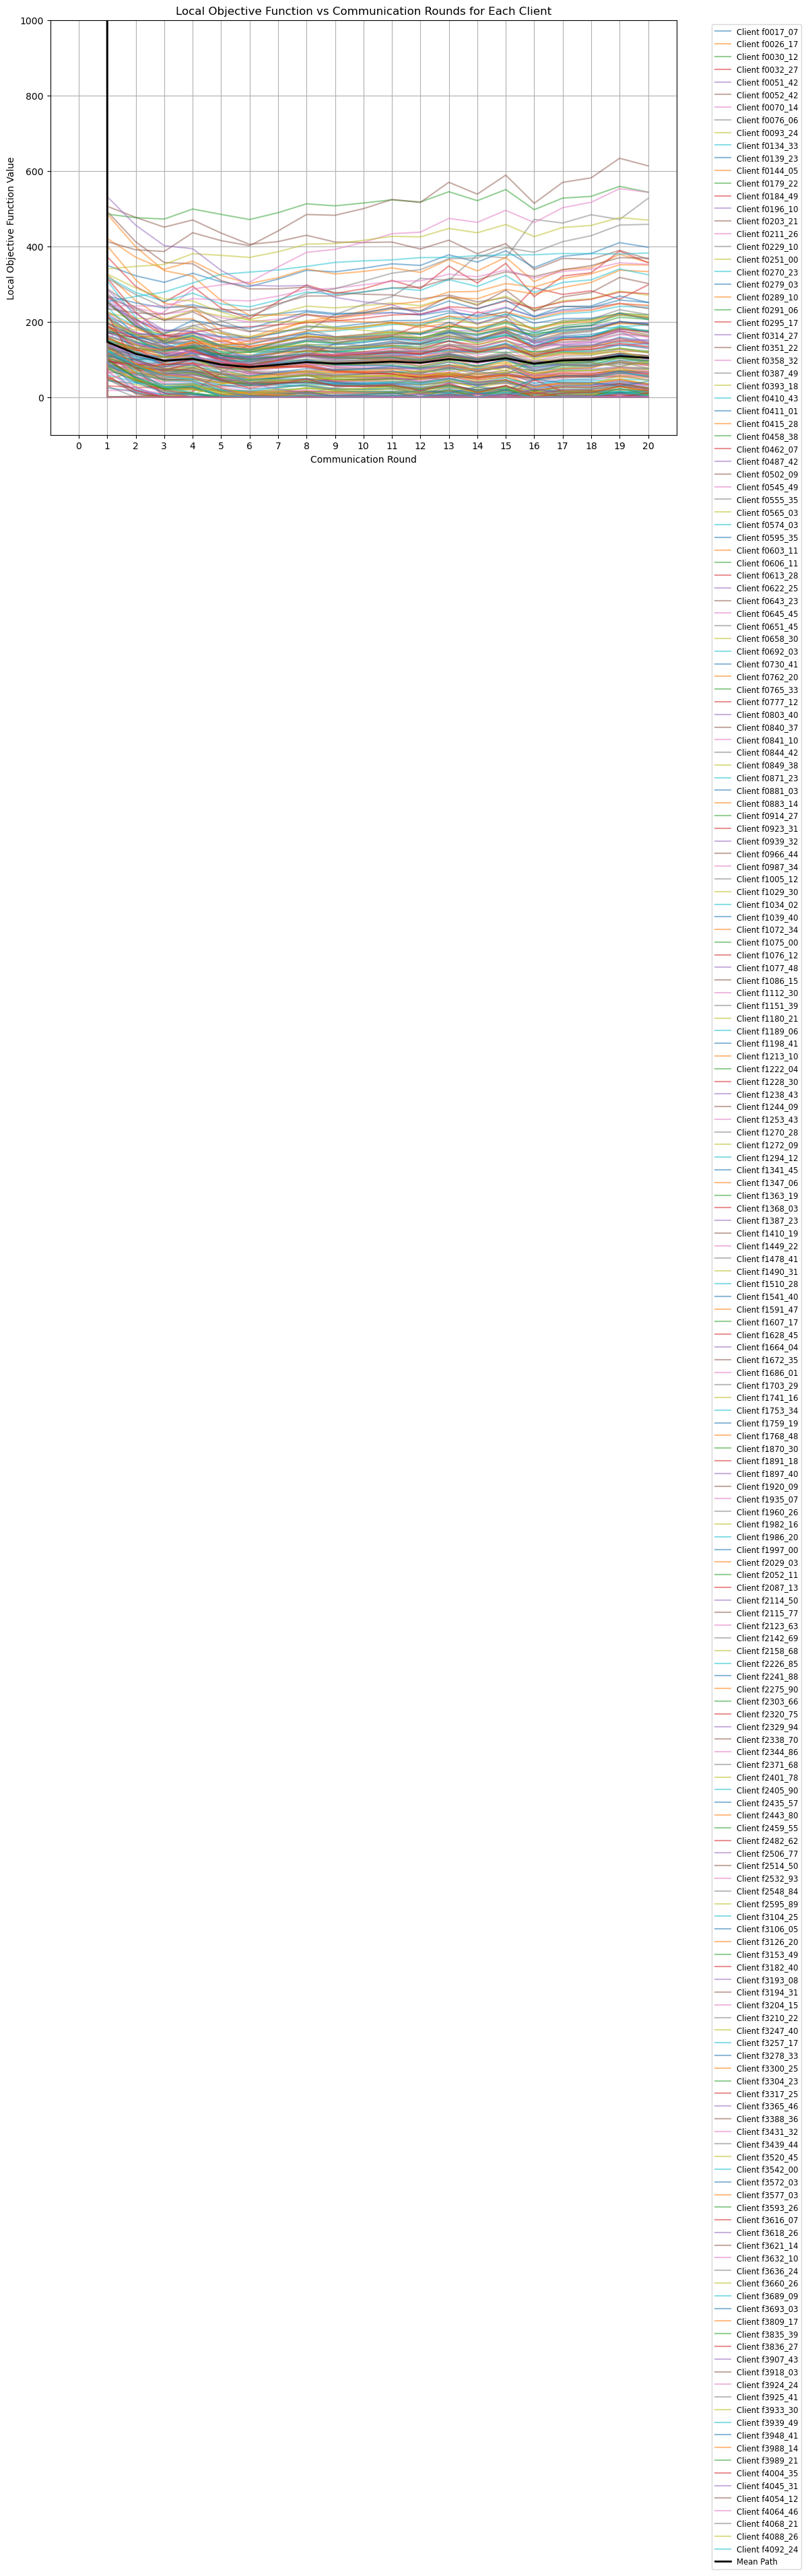

In [98]:
import matplotlib.pyplot as plt
import numpy as np

local_objective_values = {client: [] for client in client_list}

for x_val in x_global_list:
    for client in client_list:
        obj_val = obj_f(U[client].T, np.array([v[client]]), x_val)
        local_objective_values[client].append(obj_val)

mean_objective_values = np.mean([local_objective_values[client] for client in client_list], axis=0)

plt.figure(figsize=(12, 8))

for client, obj_values in local_objective_values.items():
    plt.plot(range(len(obj_values)), obj_values, label=f'Client {client}', alpha=0.5)

plt.plot(
    range(len(mean_objective_values)),
    mean_objective_values,
    color="black",
    linewidth=2,
    label="Mean Path",
)

plt.xlabel('Communication Round')
plt.ylabel('Local Objective Function Value')
plt.xticks(communication_rounds)
plt.title('Local Objective Function vs Communication Rounds for Each Client')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(True)
plt.ylim(-100,1000)
plt.tight_layout()

plt.show()

In [ ]:
# Approaches for homogeneous version of dataset
# 1 - all clients get identical datasets
# 2 - all clients get same number of a's, b's, ... j's with identical distribution of each
    # - randomly sampled from entire dataset, not broken down by client
# 3 - take a subset of the entire dataset, shuffle it and randomly distribute to all clients
# 4 - all clients get identical distribution of a's, b's, ... j's, but not necessarily same number of each letter



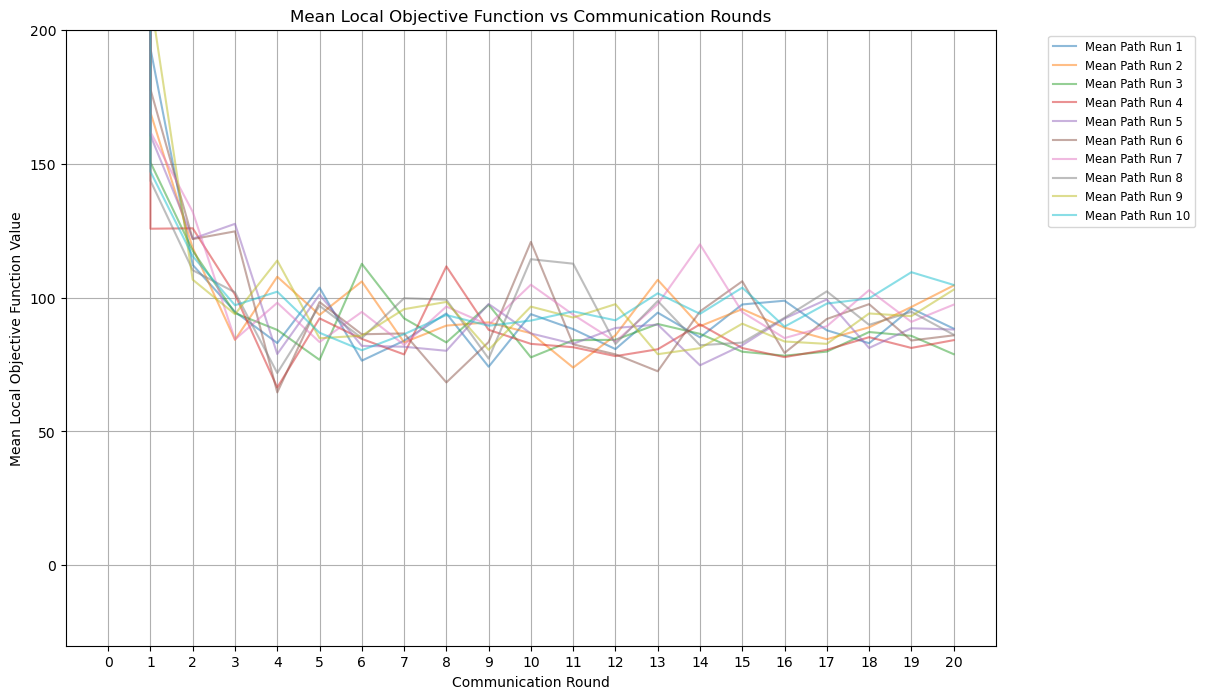

In [127]:
import matplotlib.pyplot as plt
import numpy as np

local_objective_values_by_run = []

for run_sample_path in all_sample_paths:
    local_objective_values = {client: [] for client in client_list}
    for x_val in run_sample_path:
        for client in client_list:
            obj_val = obj_f(U[client].T, np.array([v[client]]), x_val)
            local_objective_values[client].append(obj_val)
    local_objective_values_by_run.append(local_objective_values)

mean_objective_values_by_run = []
for run_obj_vals in local_objective_values_by_run:
    mean_obj_vals = np.mean([run_obj_vals[client] for client in client_list], axis=0)
    mean_objective_values_by_run.append(mean_obj_vals)

overall_mean_objective_values = np.mean(mean_objective_values_by_run, axis=0)

plt.figure(figsize=(12, 8))

for run_idx, mean_obj_vals in enumerate(mean_objective_values_by_run):
    plt.plot(
        range(len(mean_obj_vals)),
        mean_obj_vals,
        label=f'Mean Path Run {run_idx + 1}',
        alpha=0.5,
    )

# plt.plot(
#     range(len(overall_mean_objective_values)),
#     overall_mean_objective_values,
#     color="black",
#     linewidth=2,
#     label="Overall Mean Path",
# )

plt.xlabel('Communication Round')
plt.xticks(communication_rounds)
plt.ylabel('Mean Local Objective Function Value')
plt.xticks(communication_rounds)
plt.ylim(-30,200)
plt.grid(True)
plt.title('Mean Local Objective Function vs Communication Rounds')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')


In [187]:
import numpy as np
import matplotlib.pyplot as plt

# One run of federated averaging
def federated_averaging_run():
    x_global_list = [x_global]
    x_epoch_vals_by_client = {c: [] for c in client_list}
    local_objective_values = {c: [] for c in client_list}

    for r in range(R):
        curr_global = x_global_list[-1]
        next_global = np.zeros((784, 1))

        for c in client_list:
            N_curr = len(U[c])
            k_max_SGD = int(N_curr * n_epoch / minibatch_size)
            epoch_length_SGD = k_max_SGD // n_epoch

            SGD_result = SGD(curr_global, c, k_max_SGD, stepsize, epoch_length_SGD, minibatch_size)
            x_epoch_vals_by_client[c].extend(list(SGD_result.values()))
            curr_local_sol = x_epoch_vals_by_client[c][-1]

            next_global += curr_local_sol * N_curr

        x_global_list.append(next_global / N_total)

        for c in client_list:
            obj_val = obj_f(U[c].T, np.array([v[c]]), x_global_list[-1])
            local_objective_values[c].append(obj_val)

    return local_objective_values

np.random.seed(42)

# Run federated averaging with 10 different seeds
runs = {}
for i in range(10):
    np.random.seed(42 + i)
    runs[i] = federated_averaging_run()

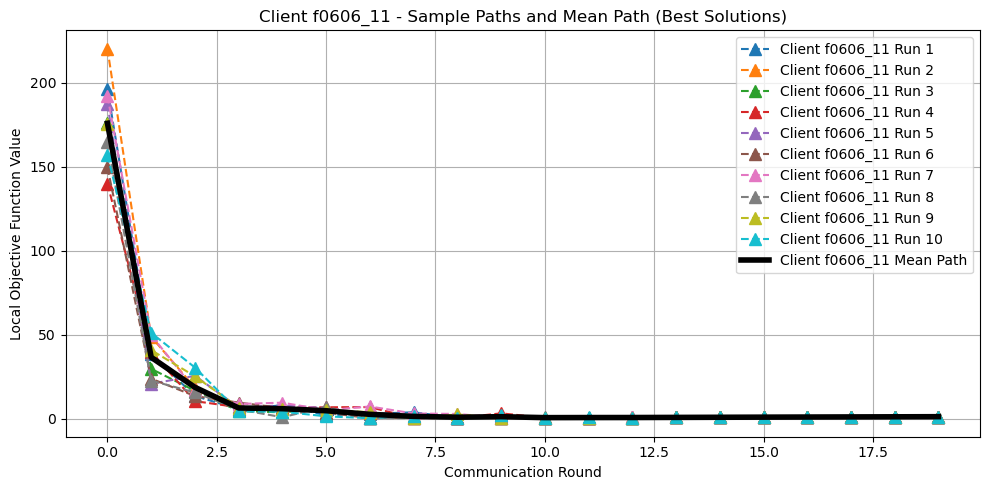

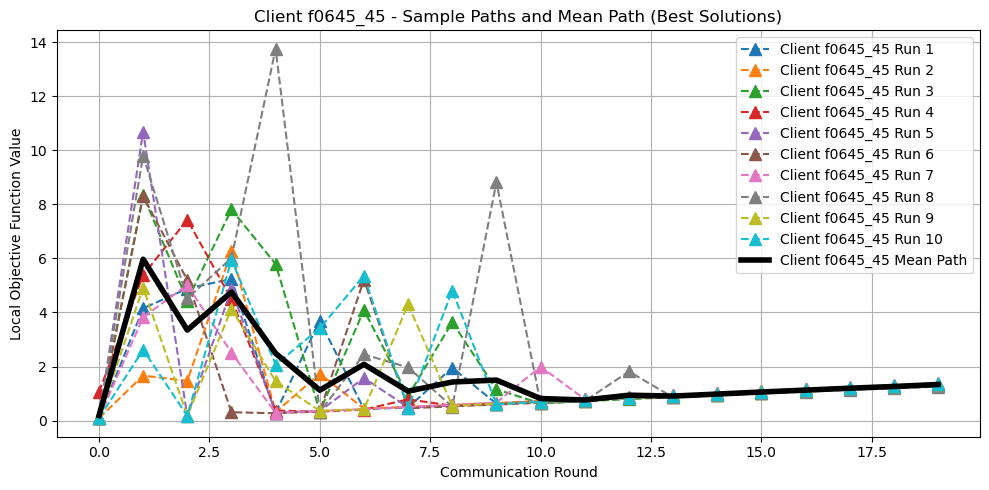

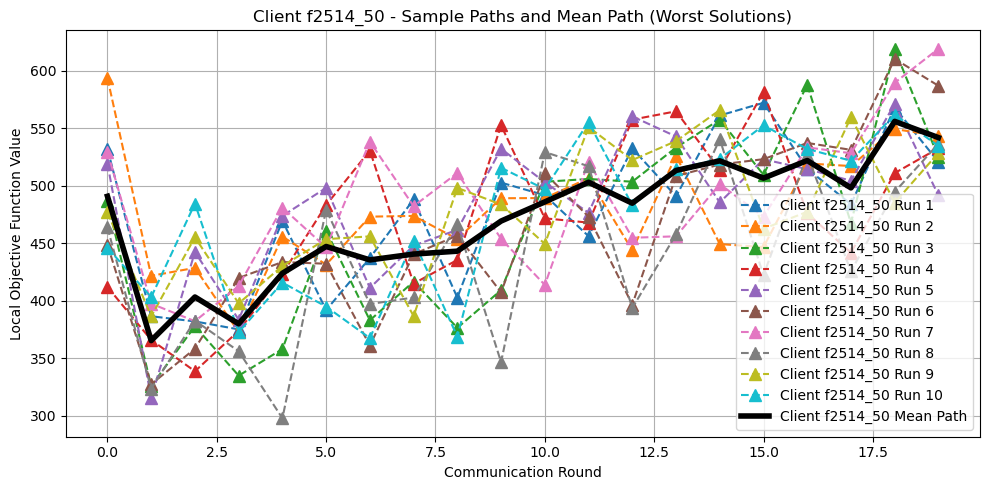

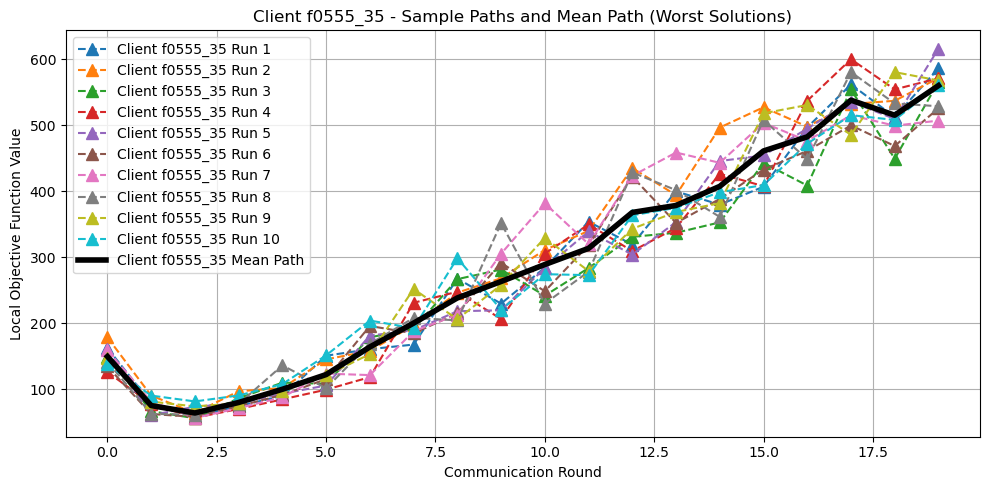

In [217]:
# Compute the mean paths for all clients across 10 runs
mean_paths = dict()

for c in client_list:
    
    client_mean_path = []    
    
    for j in range(len(runs[0][c])):
    
        sum_values = 0
        
        for i in range(10):
            sum_values += runs[i][c][j]
        
        client_mean_path.append(sum_values / 10)
    
    mean_paths[c] = client_mean_path

final_obj_values = {c: mean_paths[c][-1] for c in client_list}
sorted_clients = sorted(final_obj_values, key=final_obj_values.get)

best_clients = sorted_clients[:2]
worst_clients = sorted_clients[-2:]

for idx, client in enumerate(best_clients + worst_clients):
    
    plt.figure(figsize=(10, 5))

    # sample paths
    for i in range(10):
        plt.plot(range(len(runs[i][client])), runs[i][client], label=f'Client {client} Run {i+1}', marker='^', linestyle='--', markersize=8)
    
    # mean paths
    plt.plot(range(len(mean_paths[client])), mean_paths[client], label=f'Client {client} Mean Path', linewidth=4, color='black')
    
    plt.xlabel('Communication Round')
    plt.ylabel('Local Objective Function Value')
    
    if idx == 0 or idx == 1:
        plt.title(f'Client {client} - Sample Paths and Mean Path (Best Solutions)')
    else:
        plt.title(f'Client {client} - Sample Paths and Mean Path (Worst Solutions)')
        
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout() 
    plt.show()

